# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- **Nama:** Hafiz Nazwa Nugraha
- **Email:** hafiznugraha04@gmail.com
- **ID Dicoding:** FIshiwak

---

## Business Understanding

**Jaya Jaya Institut** adalah institusi pendidikan tinggi yang berdiri sejak tahun 2000 dan telah
mencetak banyak lulusan dengan reputasi yang sangat baik. Namun, institusi ini juga menghadapi
masalah serius: **banyak mahasiswa yang tidak menyelesaikan pendidikannya alias dropout**.

Angka dropout yang tinggi merugikan institusi dari tiga sisi sekaligus:

1. **Reputasi & akreditasi** — rasio kelulusan adalah salah satu komponen penilaian akreditasi.
2. **Pendapatan** — setiap mahasiswa yang keluar di tengah jalan berarti kehilangan uang kuliah untuk
   seluruh semester sisanya.
3. **Dampak sosial** — mahasiswa yang dropout kehilangan investasi waktu dan biaya yang sudah
   dikeluarkan, sering kali dengan sisa tunggakan.

Oleh karena itu, pihak institusi ingin **mendeteksi sedini mungkin mahasiswa yang berisiko dropout**
sehingga mereka dapat diberi bimbingan khusus sebelum benar-benar keluar. Selain itu, institusi juga
meminta sebuah **business dashboard** agar tim akademik dapat memahami data dan memonitor performa
mahasiswa secara mandiri.

### Permasalahan Bisnis

1. **Seberapa besar angka dropout Jaya Jaya Institut saat ini dan berapa mahasiswa yang terdampak?**
2. **Faktor apa saja yang paling memengaruhi keputusan mahasiswa untuk dropout?** (faktor akademik,
   finansial, demografis, maupun jalur masuk)
3. **Bagaimana mendeteksi mahasiswa berisiko dropout sedini mungkin**, idealnya pada akhir semester
   pertama, agar intervensi masih sempat dilakukan?
4. **Bagaimana tim akademik dapat memonitor performa mahasiswa secara mandiri**, tanpa harus meminta
   analisis ulang setiap kali dibutuhkan?

### Cakupan Proyek

1. **Data Understanding** — memahami struktur, kualitas, dan distribusi dataset performa mahasiswa.
2. **Exploratory Data Analysis** — menggali faktor-faktor yang berhubungan dengan dropout lewat visualisasi.
3. **Data Preparation** — membentuk target biner, menyeleksi fitur, membagi data latih/uji, dan
   membangun pipeline preprocessing.
4. **Modeling** — membandingkan tiga algoritma klasifikasi, melakukan *hyperparameter tuning*, dan
   menyetel *decision threshold* sesuai kebutuhan bisnis.
5. **Evaluation** — mengukur performa dengan metrik yang relevan untuk deteksi dini (recall, F1,
   ROC-AUC) dan menafsirkan fitur yang paling berpengaruh.
6. **Deployment** — menyimpan model, menyiapkan data untuk business dashboard Metabase, dan
   membangun prototype Streamlit.

### Persiapan

**Sumber data:** [Students' Performance Dataset — Dicoding Academy](https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance)
(dataset asli: *Predict Students' Dropout and Academic Success*, UCI Machine Learning Repository).

**Setup environment:**

```bash
python -m venv .venv
.venv\Scripts\activate          # Windows  (source .venv/bin/activate di Linux/macOS)
pip install -r requirements.txt
```

### Menyiapkan Library

Analisis menggunakan pustaka standar ekosistem data science Python: `pandas` & `numpy` untuk
manipulasi data, `matplotlib` & `seaborn` untuk visualisasi, serta `scikit-learn` untuk pemodelan.
Agar hasil dapat direproduksi, `RANDOM_STATE` dikunci pada angka 42.

In [1]:
import json
import sqlite3
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import sklearn
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)

pandas      : 2.2.3
numpy       : 2.1.3
scikit-learn: 1.6.1


#### Konfigurasi gaya visualisasi

Seluruh grafik pada notebook ini memakai satu sistem warna yang konsisten agar mudah dibaca dan tetap
dapat dibedakan pembaca dengan *color vision deficiency*:

| Peran | Warna | Dipakai untuk |
|---|---|---|
| Seri 1 (biru) | `#2a78d6` | seri data netral / nilai tunggal |
| Seri 2 (oranye) | `#eb6834` | seri pembanding |
| Status *critical* (merah) | `#d03b3b` | kategori **Dropout** |
| Status *warning* (kuning) | `#fab219` | kategori **Enrolled** |
| Status *good* (hijau) | `#0ca30c` | kategori **Graduate** |

Prinsip desain yang diterapkan: **satu sumbu** untuk satu grafik (tidak pernah *dual-axis* yang
menyesatkan), *gridline* tipis yang tidak bersaing dengan data, **label nilai langsung** pada mark
sehingga pembaca tidak perlu mengira-ngira, dan warna yang mengikuti **makna** (merah selalu berarti
dropout) — bukan mengikuti urutan besar-kecil. Setiap grafik juga diberi judul yang menyatakan
temuannya, bukan sekadar nama variabel.

In [2]:
# --- sistem warna & gaya grafik (dipakai seluruh notebook) ---
SURFACE, INK, INK_SOFT, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
C_DROPOUT, C_ENROLLED, C_GRADUATE = "#d03b3b", "#fab219", "#0ca30c"
STATUS_COLORS = {"Dropout": C_DROPOUT, "Enrolled": C_ENROLLED, "Graduate": C_GRADUATE}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 10, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "figure.dpi": 110, "font.size": 10,
})


def strip_chrome(ax, keep_y=False):
    # hilangkan garis pinggir yang tidak perlu agar data yang menonjol
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_visible(keep_y)
    ax.spines["bottom"].set_color("#c3c2b7")


def subtitle(ax, text):
    # tambahkan baris penjelas di bawah judul
    ax.set_title(ax.get_title() + "\n" + text, loc="left")


%matplotlib inline

### Menyiapkan Data

Dataset disimpan pada berkas `data.csv` yang memakai **titik koma (`;`) sebagai pemisah kolom**,
sehingga harus dibaca dengan parameter `sep=";"`.

In [3]:
df = pd.read_csv("data.csv", sep=";")
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]:,}")
df.head()

Jumlah baris : 4,424
Jumlah kolom : 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Dataset berisi **4.424 catatan mahasiswa** dengan **37 kolom**. Kolom `Status` adalah label hasil akhir
studi dengan tiga kemungkinan nilai: `Dropout`, `Enrolled` (masih aktif kuliah), dan `Graduate` (lulus).
36 kolom sisanya adalah fitur yang terekam saat pendaftaran dan selama dua semester pertama:

| Kelompok | Contoh kolom | Keterangan |
|---|---|---|
| **Demografi** | `Marital_status`, `Gender`, `Age_at_enrollment`, `Nacionality`, `International`, `Displaced` | Latar belakang pribadi mahasiswa |
| **Latar belakang keluarga** | `Mothers_qualification`, `Fathers_qualification`, `Mothers_occupation`, `Fathers_occupation` | Pendidikan & pekerjaan orang tua |
| **Jalur masuk & bekal awal** | `Application_mode`, `Application_order`, `Course`, `Admission_grade`, `Previous_qualification_grade`, `Daytime_evening_attendance` | Bagaimana dan dengan bekal apa mahasiswa masuk |
| **Finansial & administratif** | `Tuition_fees_up_to_date`, `Debtor`, `Scholarship_holder`, `Educational_special_needs` | Status pembayaran dan bantuan biaya |
| **Performa akademik** | `Curricular_units_1st/2nd_sem_*` (credited, enrolled, evaluations, approved, grade, without_evaluations) | Mata kuliah yang diambil vs lulus, beserta nilainya |
| **Kondisi makroekonomi** | `Unemployment_rate`, `Inflation_rate`, `GDP` | Kondisi ekonomi pada tahun angkatan tersebut |

Sebagian besar kolom kategorikal sudah **dikodekan sebagai angka** (misalnya `Course = 9500` berarti
program studi *Nursing*), sehingga perlu diterjemahkan kembali agar visualisasi mudah dipahami.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [5]:
print("Jumlah nilai kosong (missing value) :", int(df.isna().sum().sum()))
print("Jumlah baris duplikat               :", int(df.duplicated().sum()))
print("\nKomposisi tipe data:")
print(df.dtypes.value_counts().to_string())

Jumlah nilai kosong (missing value) : 0
Jumlah baris duplikat               : 0

Komposisi tipe data:
int64      29
float64     7
object      1


**Catatan kualitas data:** dataset **bersih** — tidak ada satu pun nilai kosong dan tidak ada baris
duplikat. Karena itu tahap *data preparation* tidak memerlukan imputasi ataupun penghapusan duplikat;
fokus preprocessing cukup pada encoding kategori, penskalaan fitur numerik, dan seleksi fitur.

In [6]:
df.describe().T[["mean", "std", "min", "50%", "max"]].round(2).head(20)

,mean,std,min,50%,max
Marital_status,1.18,0.61,1.0,1.0,6.0
Application_mode,18.67,17.48,1.0,17.0,57.0
Application_order,1.73,1.31,0.0,1.0,9.0
Course,8856.64,2063.57,33.0,9238.0,9991.0
Daytime_evening_attendance,0.89,0.31,0.0,1.0,1.0
Previous_qualification,4.58,10.22,1.0,1.0,43.0
Previous_qualification_grade,132.61,13.19,95.0,133.1,190.0
Nacionality,1.87,6.91,1.0,1.0,109.0
Mothers_qualification,19.56,15.60,1.0,19.0,44.0
Fathers_qualification,22.28,15.34,1.0,19.0,44.0


### Distribusi Status Mahasiswa

Pertanyaan bisnis pertama: **seberapa besar sebenarnya masalah dropout ini?**

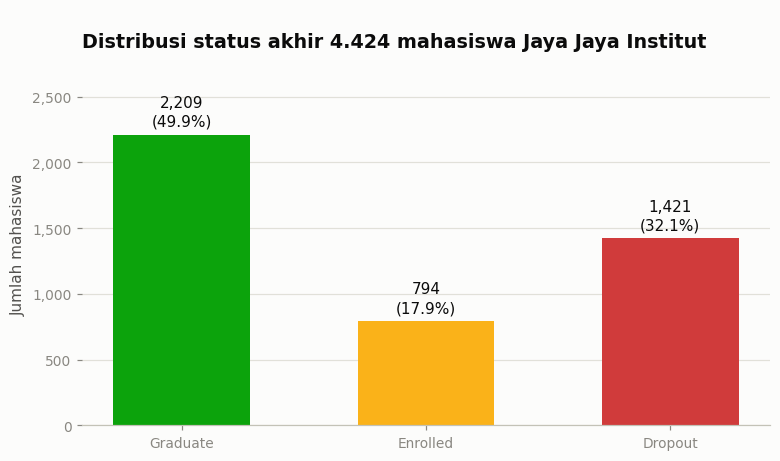

Dropout rate keseluruhan: 32.12%  (1,421 mahasiswa)


In [7]:
status_counts = df["Status"].value_counts().reindex(["Graduate", "Enrolled", "Dropout"])
status_pct = status_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(7.2, 4.3))
bars = ax.bar(status_counts.index, status_counts.values,
              color=[STATUS_COLORS[s] for s in status_counts.index], width=0.56)
for bar, n, pct in zip(bars, status_counts.values, status_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 45, f"{n:,}\n({pct:.1f}%)",
            ha="center", va="bottom", color=INK, fontsize=10, linespacing=1.3)

ax.set_title("Hampir 1 dari 3 mahasiswa berakhir dropout")
subtitle(ax, "Distribusi status akhir 4.424 mahasiswa Jaya Jaya Institut")
ax.set_ylabel("Jumlah mahasiswa")
ax.set_ylim(0, status_counts.max() * 1.25)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", visible=False)
strip_chrome(ax)
plt.tight_layout(); plt.show()

DROPOUT_RATE = (df["Status"] == "Dropout").mean() * 100
print(f"Dropout rate keseluruhan: {DROPOUT_RATE:.2f}%  "
      f"({int((df['Status'] == 'Dropout').sum()):,} mahasiswa)")

**Insight:** dari 4.424 mahasiswa, **1.421 orang (32,1%) berakhir dropout** — hampir sepertiga populasi —
dan hanya 49,9% yang berhasil lulus. Sebagai pembanding, tingkat dropout pendidikan tinggi yang umum
dianggap wajar berada di kisaran 10–15%. Artinya angka Jaya Jaya Institut **dua kali lipat lebih tinggi**
dari batas wajar. Kabar baiknya untuk pemodelan: kelas "dropout" bukan kelas langka, sehingga model
dapat belajar dari sampel yang cukup banyak tanpa teknik *oversampling* yang rumit.

## Exploratory Data Analysis

Agar grafik dapat dibaca oleh tim akademik (bukan hanya oleh data scientist), kode kategorikal
diterjemahkan lebih dulu menjadi label yang bermakna. Peta kode berikut mengikuti dokumentasi resmi
dataset di UCI Machine Learning Repository.

In [8]:
COURSE_MAP = {
    33: "Biofuel Production Technologies", 171: "Animation & Multimedia Design",
    8014: "Social Service (kelas malam)", 9003: "Agronomy", 9070: "Communication Design",
    9085: "Veterinary Nursing", 9119: "Informatics Engineering", 9130: "Equinculture",
    9147: "Management", 9238: "Social Service", 9254: "Tourism", 9500: "Nursing",
    9556: "Oral Hygiene", 9670: "Advertising & Marketing Management",
    9773: "Journalism & Communication", 9853: "Basic Education", 9991: "Management (kelas malam)",
}
MARITAL_MAP = {1: "Lajang", 2: "Menikah", 3: "Janda/Duda", 4: "Bercerai",
               5: "Kumpul kebo", 6: "Pisah secara hukum"}
APPMODE_MAP = {
    1: "Fase 1 - kuota umum", 2: "Ordinance No. 612/93",
    5: "Fase 1 - kuota khusus (Azores)", 7: "Pemegang gelar pendidikan tinggi lain",
    10: "Ordinance No. 854-B/99", 15: "Mahasiswa internasional (S1)",
    16: "Fase 1 - kuota khusus (Madeira)", 17: "Fase 2 - kuota umum", 18: "Fase 3 - kuota umum",
    26: "Ordinance 533-A/99 b2 (beda kurikulum)", 27: "Ordinance 533-A/99 b3 (institusi lain)",
    39: "Usia di atas 23 tahun", 42: "Transfer", 43: "Pindah program studi",
    44: "Pemegang diploma spesialisasi teknologi", 51: "Pindah institusi/prodi",
    53: "Pemegang diploma short cycle", 57: "Pindah institusi/prodi (internasional)",
}
YESNO = {1: "Ya", 0: "Tidak"}

eda = df.copy()
eda["is_dropout"] = (eda["Status"] == "Dropout").astype(int)
eda["Program Studi"] = eda["Course"].map(COURSE_MAP)
eda["Status Pernikahan"] = eda["Marital_status"].map(MARITAL_MAP)
eda["Jalur Masuk"] = eda["Application_mode"].map(APPMODE_MAP)
eda["Jenis Kelamin"] = eda["Gender"].map({1: "Laki-laki", 0: "Perempuan"})
eda["Kelas"] = eda["Daytime_evening_attendance"].map({1: "Siang", 0: "Malam"})
eda["SPP Lunas"] = eda["Tuition_fees_up_to_date"].map(YESNO)
eda["Penerima Beasiswa"] = eda["Scholarship_holder"].map(YESNO)
eda["Punya Tunggakan"] = eda["Debtor"].map(YESNO)
eda["Mahasiswa Pindahan/Displaced"] = eda["Displaced"].map(YESNO)

print("Kolom label siap dipakai untuk visualisasi & dashboard.")
eda[["Program Studi", "Jalur Masuk", "SPP Lunas", "Status"]].head()

Kolom label siap dipakai untuk visualisasi & dashboard.


,Program Studi,Jalur Masuk,SPP Lunas,Status
0,Animation & Multimedia Design,Fase 2 - kuota umum,Ya,Dropout
1,Tourism,Mahasiswa internasional (S1),Tidak,Graduate
2,Communication Design,Fase 1 - kuota umum,Tidak,Dropout
3,Journalism & Communication,Fase 2 - kuota umum,Ya,Graduate
4,Social Service (kelas malam),Usia di atas 23 tahun,Ya,Graduate


### 1. Faktor finansial & administratif

Hipotesis pertama: mahasiswa yang bermasalah dengan biaya kuliah lebih rentan berhenti. Empat variabel
diperiksa berdampingan sebagai *small multiples* — bentuk yang lebih jujur daripada satu grafik bertumpuk,
karena setiap panel memakai skala yang sama sehingga besarannya langsung dapat dibandingkan. Garis putus-putus
adalah **dropout rate rata-rata institusi (32,1%)** sebagai titik acuan.

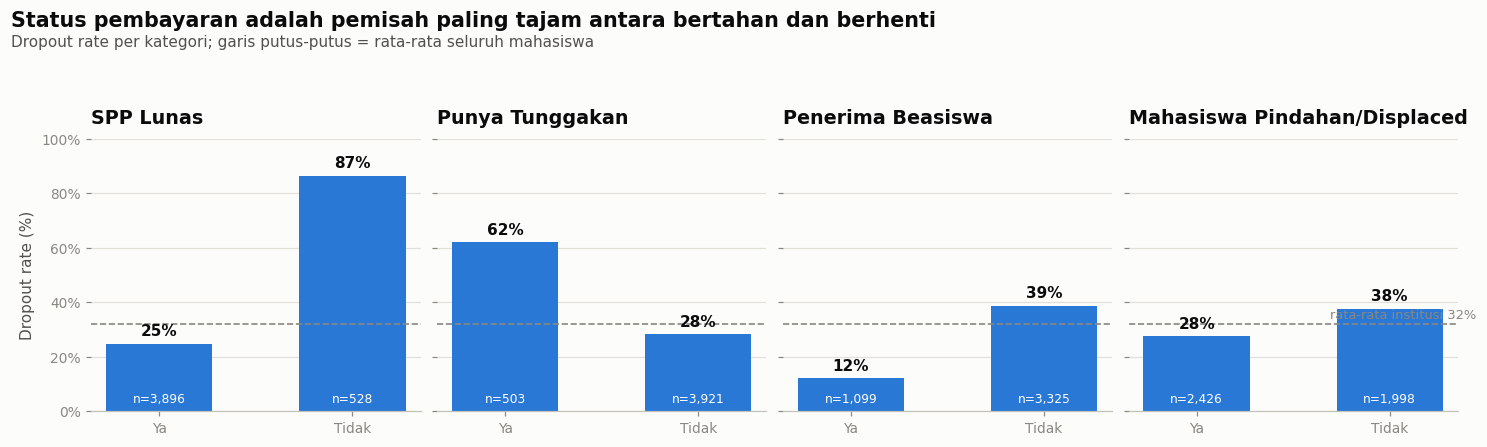

In [9]:
fin_factors = ["SPP Lunas", "Punya Tunggakan", "Penerima Beasiswa", "Mahasiswa Pindahan/Displaced"]

fig, axes = plt.subplots(1, 4, figsize=(13.5, 4.1), sharey=True)
for ax, col in zip(axes, fin_factors):
    g = eda.groupby(col)["is_dropout"].agg(["mean", "count"]).reindex(["Ya", "Tidak"])
    rate = g["mean"] * 100
    bars = ax.bar(rate.index, rate.values, color=BLUE, width=0.55)
    for bar, v, n in zip(bars, rate.values, g["count"]):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1.8, f"{v:.0f}%",
                ha="center", va="bottom", color=INK, fontsize=10, fontweight="bold")
        ax.text(bar.get_x() + bar.get_width() / 2, 2, f"n={int(n):,}",
                ha="center", va="bottom", color="#ffffff", fontsize=8)
    ax.axhline(DROPOUT_RATE, color=MUTED, linestyle="--", linewidth=1.1)
    ax.set_title(col)
    ax.set_ylim(0, 100)
    ax.grid(axis="x", visible=False)
    strip_chrome(ax)
axes[0].set_ylabel("Dropout rate (%)")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
axes[-1].text(1.45, DROPOUT_RATE + 2, f"rata-rata institusi {DROPOUT_RATE:.0f}%",
              color=MUTED, fontsize=8.5, ha="right")
fig.suptitle("Status pembayaran adalah pemisah paling tajam antara bertahan dan berhenti",
             x=0.005, ha="left", fontsize=13.5, fontweight="bold", color=INK)
fig.text(0.005, 0.90, "Dropout rate per kategori; garis putus-putus = rata-rata seluruh mahasiswa",
         ha="left", fontsize=10, color=INK_SOFT)
plt.tight_layout(rect=[0, 0, 1, 0.88]); plt.show()

**Insight:**

- **SPP tidak lunas adalah sinyal bahaya terkuat.** Mahasiswa yang tunggakan SPP-nya belum lunas memiliki
  dropout rate **86,6%** — hampir tiga kali lipat rata-rata institusi — dibanding 24,7% pada mahasiswa yang
  pembayarannya lancar. Dari 528 mahasiswa yang menunggak, 457 di antaranya berhenti kuliah.
- **Status *debtor* menggandakan risiko** (62,0% vs 28,3%).
- **Beasiswa berfungsi sebagai pelindung:** penerima beasiswa hanya dropout 12,2%, sepertiga dari yang
  bukan penerima (38,7%). Ini sinyal kuat bahwa hambatan finansial — bukan semata kemampuan akademik —
  ikut mendorong mahasiswa keluar.

### 2. Faktor demografis dan jalur masuk

Berikutnya, apakah profil mahasiswa saat mendaftar sudah membawa risiko bawaan? Usia saat mendaftar
dikelompokkan menjadi rentang berurutan, sehingga tepat digambarkan dengan **ramp satu warna** dari terang
ke gelap (kategori berurutan, bukan identitas yang setara).

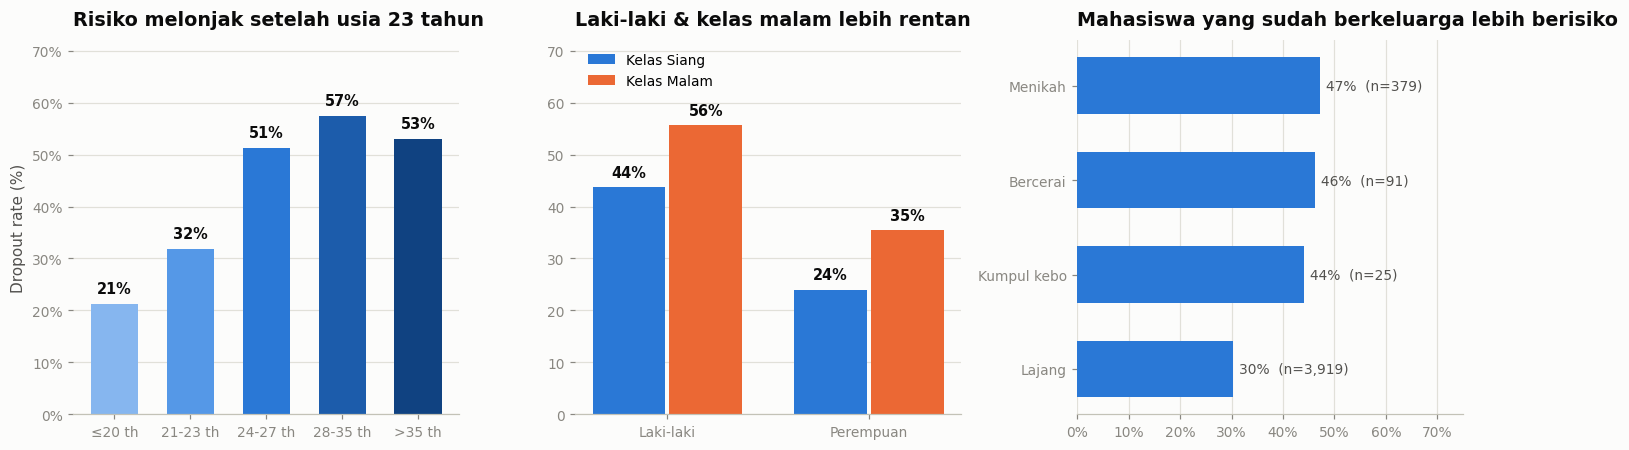

In [10]:
age_bins = [16, 20, 23, 27, 35, 100]
age_labels = ["≤20 th", "21-23 th", "24-27 th", "28-35 th", ">35 th"]
eda["Kelompok Usia"] = pd.cut(eda["Age_at_enrollment"], bins=age_bins, labels=age_labels, right=True)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

# (a) usia — kategori berurutan -> ordinal ramp satu hue
g_age = eda.groupby("Kelompok Usia", observed=True)["is_dropout"].agg(["mean", "count"])
ramp = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
bars = axes[0].bar(g_age.index.astype(str), g_age["mean"] * 100, color=ramp, width=0.62)
for bar, v, n in zip(bars, g_age["mean"] * 100, g_age["count"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center",
                 va="bottom", color=INK, fontsize=9.5, fontweight="bold")
axes[0].set_title("Risiko melonjak setelah usia 23 tahun")
axes[0].set_ylabel("Dropout rate (%)")

# (b) jenis kelamin & kelas
combo = (eda.groupby(["Jenis Kelamin", "Kelas"])["is_dropout"].mean() * 100).unstack()
combo = combo[["Siang", "Malam"]]
x = np.arange(len(combo.index)); w = 0.36
for i, (kelas, color) in enumerate(zip(["Siang", "Malam"], [BLUE, ORANGE])):
    bars = axes[1].bar(x + (i - 0.5) * (w + 0.02), combo[kelas], width=w, color=color, label=f"Kelas {kelas}")
    for bar, v in zip(bars, combo[kelas]):
        axes[1].text(bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center",
                     va="bottom", color=INK, fontsize=9.5, fontweight="bold")
axes[1].set_xticks(x); axes[1].set_xticklabels(combo.index)
axes[1].legend(loc="upper left", fontsize=9)
axes[1].set_title("Laki-laki & kelas malam lebih rentan")

# (c) status pernikahan
g_mar = eda.groupby("Status Pernikahan")["is_dropout"].agg(["mean", "count"])
g_mar = g_mar[g_mar["count"] >= 20].sort_values("mean")
bars = axes[2].barh(g_mar.index, g_mar["mean"] * 100, color=BLUE, height=0.6)
for bar, v, n in zip(bars, g_mar["mean"] * 100, g_mar["count"]):
    axes[2].text(v + 1.2, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%  (n={int(n):,})",
                 va="center", color=INK_SOFT, fontsize=9)
axes[2].set_title("Mahasiswa yang sudah berkeluarga lebih berisiko")
axes[2].set_xlim(0, 75)
axes[2].grid(axis="y", visible=False)

for ax in axes[:2]:
    ax.set_ylim(0, 72); ax.grid(axis="x", visible=False)
for ax in axes:
    strip_chrome(ax)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.tight_layout(); plt.show()

**Insight:**

- **Usia saat mendaftar berbanding lurus dengan risiko.** Mahasiswa berusia ≤20 tahun dropout 21,2%,
  sedangkan yang mendaftar di atas 24 tahun berada di kisaran 51–58%. Mahasiswa yang masuk lebih tua umumnya sudah
  bekerja atau punya tanggungan keluarga, sehingga kuliah bersaing dengan prioritas lain.
- **Mahasiswa laki-laki** dropout jauh lebih sering (45,1%) dibanding perempuan (25,1%).
- **Kelas malam lebih rentan** daripada kelas siang, pola yang konsisten dengan temuan usia — kelas malam
  banyak diisi mahasiswa yang bekerja.
- **Mahasiswa yang sudah menikah/bercerai** dropout di kisaran 46–47%, jauh di atas mahasiswa lajang (30,2%).

### 3. Performa akademik dua semester pertama

Bagian ini paling penting untuk **deteksi dini**: apakah hasil semester pertama sudah cukup untuk menebak
siapa yang akan keluar? Yang dibandingkan adalah **jumlah mata kuliah yang lulus** dan **rata-rata nilai**
per status.

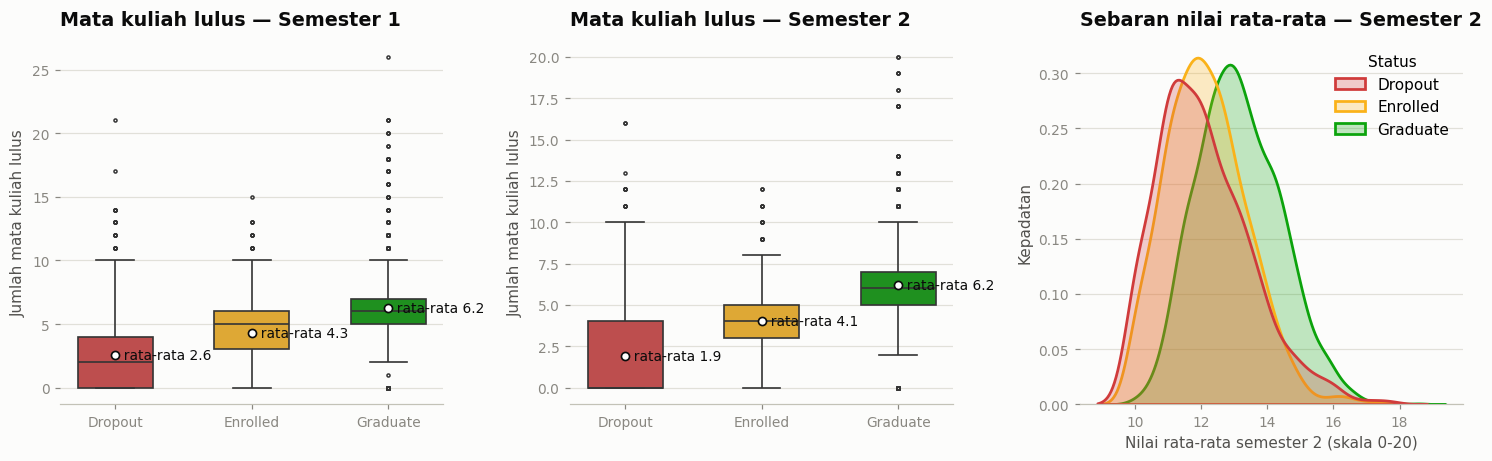

          Curricular_units_1st_sem_enrolled  Curricular_units_1st_sem_approved  Curricular_units_1st_sem_grade  Curricular_units_2nd_sem_enrolled  Curricular_units_2nd_sem_approved  Curricular_units_2nd_sem_grade
Status                                                                                                                                                                                                              
Dropout                                5.82                               2.55                            7.26                               5.78                               1.94                            5.90
Enrolled                               5.96                               4.32                           11.13                               5.94                               4.06                           11.12
Graduate                               6.67                               6.23                           12.64                               6.63   

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3))
order = ["Dropout", "Enrolled", "Graduate"]
pal = [STATUS_COLORS[s] for s in order]

# (a) & (b) distribusi mata kuliah lulus per semester
for ax, sem, label in zip(axes[:2], ["1st", "2nd"], ["Semester 1", "Semester 2"]):
    col = f"Curricular_units_{sem}_sem_approved"
    sns.boxplot(data=eda, x="Status", y=col, order=order, palette=pal, ax=ax,
                width=0.55, fliersize=2, linewidth=1.1)
    means = eda.groupby("Status")[col].mean().reindex(order)
    for i, m in enumerate(means):
        ax.text(i, m, f"  rata-rata {m:.1f}", va="center", ha="left", color=INK, fontsize=9)
        ax.scatter([i], [m], color="#ffffff", edgecolor=INK, zorder=5, s=28, linewidth=1.1)
    ax.set_title(f"Mata kuliah lulus — {label}")
    ax.set_ylabel("Jumlah mata kuliah lulus")
    ax.set_xlabel("")
    ax.grid(axis="x", visible=False)
    strip_chrome(ax)

# (c) rata-rata nilai semester 2
sns.kdeplot(data=eda[eda["Curricular_units_2nd_sem_grade"] > 0], x="Curricular_units_2nd_sem_grade",
            hue="Status", hue_order=order, palette=pal, ax=axes[2], fill=True, alpha=0.25,
            common_norm=False, linewidth=1.8)
axes[2].set_title("Sebaran nilai rata-rata — Semester 2")
axes[2].set_xlabel("Nilai rata-rata semester 2 (skala 0-20)")
axes[2].set_ylabel("Kepadatan")
axes[2].grid(axis="x", visible=False)
strip_chrome(axes[2])
plt.tight_layout(); plt.show()

print(eda.groupby("Status")[["Curricular_units_1st_sem_enrolled", "Curricular_units_1st_sem_approved",
                             "Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_enrolled",
                             "Curricular_units_2nd_sem_approved", "Curricular_units_2nd_sem_grade"]]
      .mean().round(2).to_string())

**Insight:**

- **Kesenjangan sudah terlihat sejak semester pertama.** Mahasiswa yang kelak dropout rata-rata hanya lulus
  **2,6 dari 5,8 mata kuliah** yang diambil di semester 1, sementara yang lulus kuliah melulus **6,2 dari 6,7**.
  Artinya sinyal risiko sudah tersedia **jauh sebelum** mahasiswa benar-benar keluar — inilah yang membuat
  deteksi dini realistis.
- **Jurang itu melebar di semester dua**: rata-rata mata kuliah lulus kelompok dropout justru turun ke 1,9,
  dan nilai rata-ratanya anjlok ke 5,9 (dari skala 20) versus 12,7 milik kelompok lulus.
- Perhatikan bahwa **jumlah mata kuliah yang diambil hampir sama** di semua kelompok (5,8 vs 6,7). Jadi yang
  membedakan bukan beban studi, melainkan **tingkat keberhasilan menuntaskannya**.

### 4. Program studi mana yang paling bermasalah?

Untuk kategori nominal seperti program studi, seluruh batang memakai **satu warna** (panjang batang sudah
menyampaikan besarannya); warna hanya dipakai untuk **menyorot** prodi yang berada di atas rata-rata institusi.

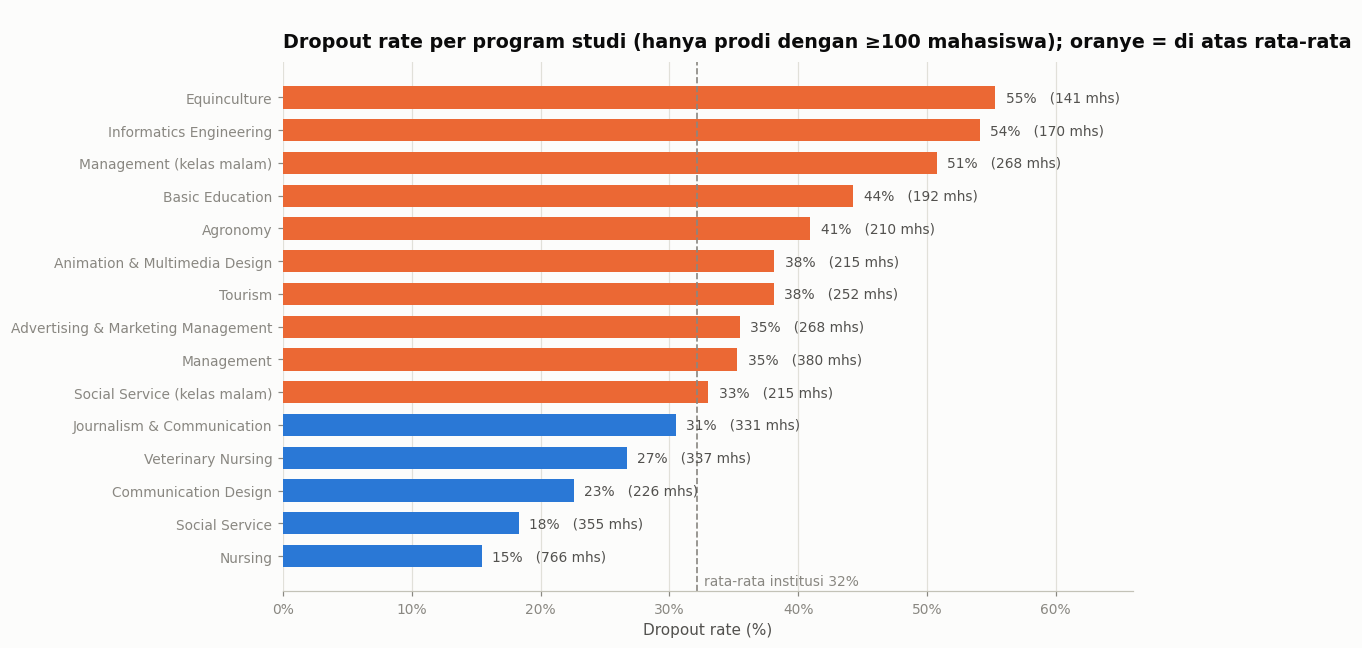

In [12]:
g_course = (eda.groupby("Program Studi")["is_dropout"].agg(["mean", "count"])
            .query("count >= 100").sort_values("mean"))
colors = [ORANGE if v > DROPOUT_RATE / 100 else BLUE for v in g_course["mean"]]

fig, ax = plt.subplots(figsize=(10.5, 6))
bars = ax.barh(g_course.index, g_course["mean"] * 100, color=colors, height=0.68)
for bar, v, n in zip(bars, g_course["mean"] * 100, g_course["count"]):
    ax.text(v + 0.8, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%   ({int(n):,} mhs)",
            va="center", color=INK_SOFT, fontsize=9)
ax.axvline(DROPOUT_RATE, color=MUTED, linestyle="--", linewidth=1.1)
ax.text(DROPOUT_RATE + 0.6, -0.9, f"rata-rata institusi {DROPOUT_RATE:.0f}%", color=MUTED, fontsize=9)
ax.set_title("Selisih dropout antarprogram studi mencapai 40 poin persen")
subtitle(ax, "Dropout rate per program studi (hanya prodi dengan ≥100 mahasiswa); oranye = di atas rata-rata")
ax.set_xlabel("Dropout rate (%)")
ax.set_xlim(0, 66)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False)
strip_chrome(ax)
plt.tight_layout(); plt.show()

**Insight:** dropout bukan masalah yang merata. **Equinculture (55,3%)**, **Informatics Engineering (54,1%)**,
dan **Management kelas malam (50,7%)** berada jauh di atas rata-rata, sedangkan **Nursing hanya 15,4%** —
selisih hampir 40 poin persen antara prodi teraman dan paling bermasalah. Prodi di sisi oranye layak diprioritaskan untuk audit
kurikulum dan penguatan bimbingan akademik.

### 5. Fitur numerik mana yang paling berkorelasi dengan dropout?

Sebagai penutup EDA, korelasi Pearson setiap fitur numerik terhadap target biner `is_dropout` diurutkan
berdasarkan kekuatannya. Grafik memakai **skema diverging biru–merah dengan titik netral di nol**: merah
berarti menaikkan risiko dropout, biru berarti menurunkannya.

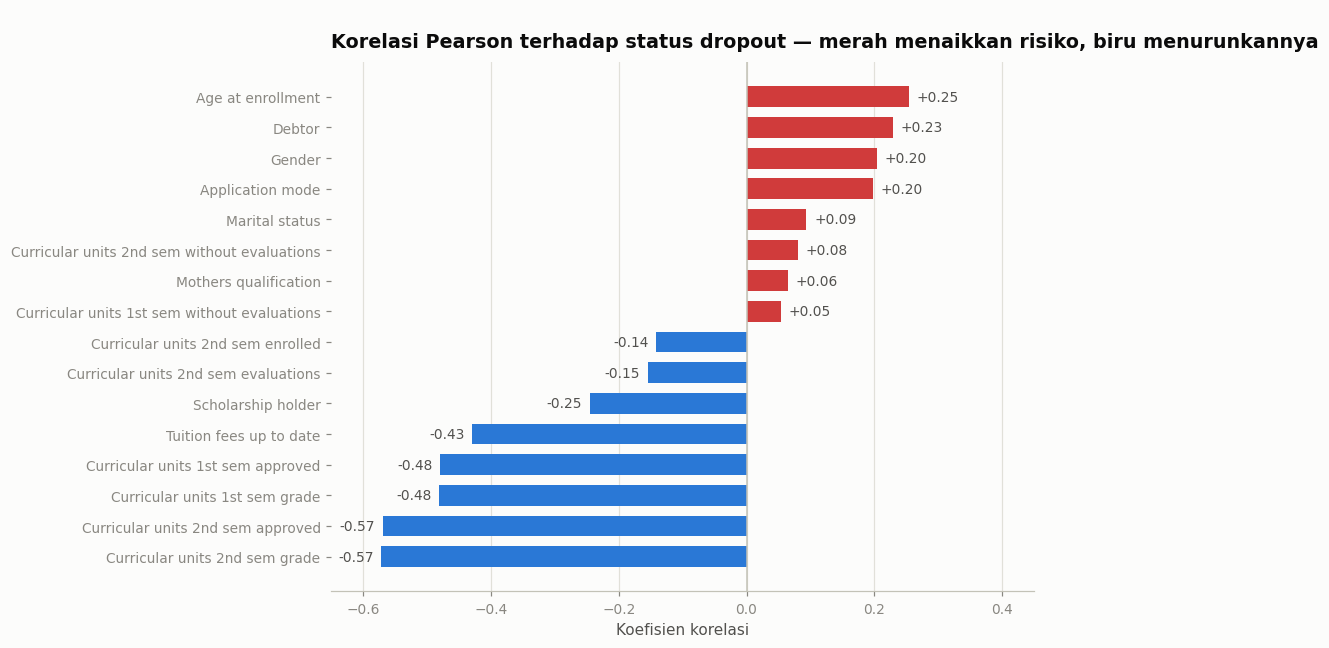

In [13]:
corr = (df.assign(is_dropout=(df["Status"] == "Dropout").astype(int))
        .drop(columns=["Status"]).corr(numeric_only=True)["is_dropout"]
        .drop("is_dropout").sort_values())
top = pd.concat([corr.head(8), corr.tail(8)]).sort_values()

fig, ax = plt.subplots(figsize=(9.6, 6))
colors = [C_DROPOUT if v > 0 else BLUE for v in top.values]
bars = ax.barh(range(len(top)), top.values, color=colors, height=0.68)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([c.replace("_", " ") for c in top.index], fontsize=9)
for bar, v in zip(bars, top.values):
    off = 0.012 if v > 0 else -0.012
    ax.text(v + off, bar.get_y() + bar.get_height() / 2, f"{v:+.2f}", va="center",
            ha="left" if v > 0 else "right", color=INK_SOFT, fontsize=9)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_title("Performa semester berjalan mengalahkan semua faktor latar belakang")
subtitle(ax, "Korelasi Pearson terhadap status dropout — merah menaikkan risiko, biru menurunkannya")
ax.set_xlabel("Koefisien korelasi")
ax.set_xlim(-0.65, 0.45)
ax.grid(axis="y", visible=False)
strip_chrome(ax)
plt.tight_layout(); plt.show()

**Insight:** korelasi terkuat dipegang oleh **nilai rata-rata semester 2 (-0,57)** dan **jumlah mata kuliah yang
lulus di semester 2 (-0,57)**, disusul kedua ukuran yang sama pada semester 1 (-0,48) dan **status pembayaran
SPP (-0,43)**. Sebaliknya, **usia saat mendaftar (+0,25)** dan **status tunggakan (+0,23)** menaikkan risiko. Variabel makroekonomi
(`Unemployment_rate`, `GDP`, `Inflation_rate`) nyaris tidak berkorelasi — masalah dropout di sini bersifat
**internal dan dapat ditindaklanjuti institusi**, bukan sekadar akibat kondisi ekonomi di luar kendali.

### Ringkasan temuan EDA

| # | Temuan | Angka kunci |
|---|---|---|
| 1 | Dropout rate institusi sangat tinggi | **32,1%** (1.421 dari 4.424 mahasiswa) |
| 2 | Tunggakan SPP adalah sinyal paling tajam | **86,6%** vs 24,7% |
| 3 | Beasiswa menekan risiko hingga sepertiga | 12,2% vs 38,7% |
| 4 | Performa semester 1 sudah membedakan sejak awal | 2,6 vs 6,2 mata kuliah lulus |
| 5 | Mahasiswa yang mendaftar di usia lebih tua lebih rentan | 21% (≤20 th) → 51–58% (>24 th) |
| 6 | Risiko sangat timpang antarprogram studi | 15,4% (Nursing) → 55,3% (Equinculture) |

## Data Preparation / Preprocessing

### a. Membentuk target biner

Kolom `Status` punya tiga nilai, tetapi kebutuhan bisnisnya adalah **peringatan dini dropout** — sebuah
pertanyaan ya/tidak. Karena itu target diubah menjadi biner:

| Status asli | Target `is_dropout` | Alasan |
|---|---|---|
| `Dropout` | **1** | kasus yang ingin dicegah |
| `Graduate` | 0 | mahasiswa berhasil menuntaskan studi |
| `Enrolled` | 0 | masih aktif kuliah, **belum** keluar |

Mahasiswa `Enrolled` sengaja **tidak dibuang**. Membuangnya akan membuat model hanya belajar dari kasus-kasus
ekstrem (lulus vs keluar) dan berperforma optimistis semu, padahal saat dipakai nanti model justru akan
menghadapi mahasiswa yang masih aktif. Konsekuensinya, sebagian mahasiswa `Enrolled` yang performanya
memburuk akan diprediksi berisiko — dan itu justru perilaku yang diinginkan untuk sistem peringatan dini.

In [14]:
data = df.copy()
data["is_dropout"] = (data["Status"] == "Dropout").astype(int)

print(data["is_dropout"].value_counts().rename({0: "Tidak dropout", 1: "Dropout"}).to_string())
print(f"\nProporsi kelas positif (dropout): {data['is_dropout'].mean():.1%}")

is_dropout
Tidak dropout    3003
Dropout          1421

Proporsi kelas positif (dropout): 32.1%


### b. Seleksi fitur

Dataset punya 36 fitur, tetapi tidak semuanya layak dipakai untuk sistem yang akan dioperasikan staf akademik:

- **Tidak informatif/terlalu jarang:** `Nacionality` dan `International` hampir seluruhnya bernilai sama;
  `Educational_special_needs` hanya dimiliki segelintir mahasiswa.
- **Di luar kendali institusi:** `Unemployment_rate`, `Inflation_rate`, `GDP` — korelasinya mendekati nol
  (lihat EDA) dan tidak bisa ditindaklanjuti.
- **Sulit diisi di lapangan:** kode kualifikasi/pekerjaan orang tua punya puluhan kategori yang jarang
  tersedia lengkap di sistem akademik.

Yang dipertahankan adalah **21 fitur** yang (a) terbukti berpengaruh pada EDA, (b) tersedia di sistem akademik
sejak awal semester, dan (c) realistis diisi manual oleh staf pada prototype. Dampak penyederhanaan ini
terhadap performa diuji langsung pada tahap modeling (model fitur-lengkap dipakai sebagai pembanding).

In [15]:
NUMERIC_FEATURES = [
    "Age_at_enrollment", "Admission_grade", "Previous_qualification_grade", "Application_order",
    "Curricular_units_1st_sem_enrolled", "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_evaluations", "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_enrolled", "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_evaluations", "Curricular_units_2nd_sem_grade",
]
BINARY_FEATURES = [
    "Tuition_fees_up_to_date", "Scholarship_holder", "Debtor", "Gender",
    "Displaced", "Daytime_evening_attendance",
]
CATEGORICAL_FEATURES = ["Marital_status", "Application_mode", "Course"]

FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES = [c for c in df.columns if c != "Status"]

X = data[FEATURES]
y = data["is_dropout"]

print(f"Fitur terpilih : {len(FEATURES)} kolom")
print(f"  - numerik    : {len(NUMERIC_FEATURES)}")
print(f"  - biner      : {len(BINARY_FEATURES)}")
print(f"  - kategorikal: {len(CATEGORICAL_FEATURES)} (akan di-one-hot encode)")
print(f"Fitur lengkap (pembanding): {len(ALL_FEATURES)} kolom")

Fitur terpilih : 21 kolom
  - numerik    : 12
  - biner      : 6
  - kategorikal: 3 (akan di-one-hot encode)
Fitur lengkap (pembanding): 36 kolom


### c. Membagi data latih dan data uji

Pembagian 80:20 dengan `stratify=y` agar proporsi dropout pada data latih dan data uji tetap sama
(32,1%). Data uji **tidak disentuh sama sekali** selama pemilihan model maupun tuning — seluruh
perbandingan model dilakukan dengan *cross-validation* pada data latih, sehingga skor akhir pada data uji
tetap menjadi estimasi yang jujur.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Data latih : {X_train.shape[0]:,} baris  (dropout {y_train.mean():.1%})")
print(f"Data uji   : {X_test.shape[0]:,} baris  (dropout {y_test.mean():.1%})")

Data latih : 3,539 baris  (dropout 32.1%)
Data uji   : 885 baris  (dropout 32.1%)


### d. Pipeline preprocessing

Preprocessing dibungkus dalam `ColumnTransformer` di dalam `Pipeline`, bukan dikerjakan manual di dataframe.
Keuntungannya: (1) tidak ada kebocoran data (*data leakage*) karena `StandardScaler` hanya di-*fit* pada
fold latih, dan (2) objek yang disimpan ke `.joblib` sudah berisi preprocessing + model, sehingga prototype
cukup memberi data mentah tanpa menduplikasi logika transformasi.

- **Fitur numerik** → `StandardScaler` (penting untuk Logistic Regression; tidak merugikan model pohon).
- **Fitur kategorikal** → `OneHotEncoder(handle_unknown="ignore")` agar kode prodi/jalur masuk yang belum
  pernah muncul tidak membuat aplikasi gagal.
- **Fitur biner** sudah bernilai 0/1 sehingga diteruskan apa adanya.

In [17]:
def build_preprocessor(numeric, categorical, passthrough):
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
            ("bin", "passthrough", passthrough),
        ],
        remainder="drop",
    )


preprocessor = build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES)
n_cols = preprocessor.fit_transform(X_train).shape[1]
print(f"Jumlah kolom setelah preprocessing: {n_cols} "
      f"(dari {len(FEATURES)} fitur, hasil one-hot encoding 3 kolom kategorikal)")

Jumlah kolom setelah preprocessing: 59 (dari 21 fitur, hasil one-hot encoding 3 kolom kategorikal)


## Modeling

### a. Memilih metrik evaluasi

Kasus ini **bukan** kasus yang pantas dinilai dengan akurasi. Menebak "semua mahasiswa aman" sudah
menghasilkan akurasi 68% tanpa menolong siapa pun. Yang menentukan nilai bisnis adalah:

| Metrik | Arti dalam konteks ini | Konsekuensi bila rendah |
|---|---|---|
| **Recall** | Berapa persen calon dropout yang **berhasil terdeteksi** | Mahasiswa berisiko luput, tidak dibimbing, lalu benar-benar keluar |
| **Precision** | Dari yang ditandai berisiko, berapa persen **benar-benar** dropout | Waktu konselor terbuang untuk mahasiswa yang sebenarnya aman |
| **F1-score** | Keseimbangan keduanya | Metrik utama pemilihan model |
| **ROC-AUC** | Kemampuan memeringkat risiko, bebas dari pilihan threshold | Prioritas penanganan jadi tidak dapat diandalkan |

**Recall lebih mahal daripada precision di sini:** biaya salah tandai hanyalah satu sesi konseling tambahan,
sementara biaya melewatkan satu mahasiswa adalah kehilangan mahasiswa itu sepenuhnya. Pertimbangan ini
diwujudkan konkret pada tahap penyetelan threshold.

### b. Membandingkan tiga algoritma

Tiga algoritma dengan karakter berbeda dibandingkan memakai **5-fold stratified cross-validation** pada
data latih:

1. **Logistic Regression** — model linier, paling mudah dijelaskan ke pihak non-teknis; jadi *baseline*.
2. **Random Forest** — ensemble pohon dengan bagging, tahan terhadap outlier dan hubungan non-linier.
3. **Gradient Boosting** — ensemble pohon bertahap yang biasanya paling akurat pada data tabular.

Ketiganya memakai `class_weight="balanced"` bila tersedia, agar kelas dropout tidak dikalahkan kelas mayoritas.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, estimator in candidates.items():
    pipe = Pipeline([("prep", build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES)),
                     ("model", estimator)])
    scores = {m: cross_val_score(pipe, X_train, y_train, cv=cv, scoring=m, n_jobs=-1)
              for m in ["f1", "recall", "precision", "roc_auc"]}
    rows.append({"Model": name,
                 "F1": scores["f1"].mean(), "F1 (std)": scores["f1"].std(),
                 "Recall": scores["recall"].mean(), "Precision": scores["precision"].mean(),
                 "ROC-AUC": scores["roc_auc"].mean()})
    print(f"{name:<22} F1={scores['f1'].mean():.4f} ± {scores['f1'].std():.4f} | "
          f"Recall={scores['recall'].mean():.4f} | ROC-AUC={scores['roc_auc'].mean():.4f}")

cv_results = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
cv_results.round(4)

Logistic Regression    F1=0.7903 ± 0.0198 | Recall=0.8012 | ROC-AUC=0.9143


Random Forest          F1=0.7814 ± 0.0183 | Recall=0.7115 | ROC-AUC=0.9135


Gradient Boosting      F1=0.7759 ± 0.0133 | Recall=0.7203 | ROC-AUC=0.9095


,Model,F1,F1 (std),Recall,Precision,ROC-AUC
0,Logistic Regression,0.7903,0.0198,0.8012,0.7802,0.9143
1,Random Forest,0.7814,0.0183,0.7115,0.8665,0.9135
2,Gradient Boosting,0.7759,0.0133,0.7203,0.8410,0.9095


Sebagai pembanding, model terbaik juga dilatih ulang memakai **seluruh 36 fitur** untuk memastikan
penyederhanaan fitur tidak mengorbankan performa secara berarti.

In [19]:
best_name = cv_results.loc[0, "Model"]
all_num = [c for c in ALL_FEATURES if c not in CATEGORICAL_FEATURES]
pipe_full = Pipeline([("prep", build_preprocessor(all_num, CATEGORICAL_FEATURES, [])),
                      ("model", candidates[best_name])])
f1_full = cross_val_score(pipe_full, data[ALL_FEATURES], y, cv=cv, scoring="f1", n_jobs=-1)

f1_sel = cv_results.loc[0, "F1"]
print(f"Model terbaik                        : {best_name}")
print(f"F1 dengan {len(FEATURES)} fitur terpilih          : {f1_sel:.4f}")
print(f"F1 dengan {len(ALL_FEATURES)} fitur lengkap           : {f1_full.mean():.4f}")
print(f"Selisih                              : {f1_full.mean() - f1_sel:+.4f}")

Model terbaik                        : Logistic Regression
F1 dengan 21 fitur terpilih          : 0.7903
F1 dengan 36 fitur lengkap           : 0.7972
Selisih                              : +0.0068


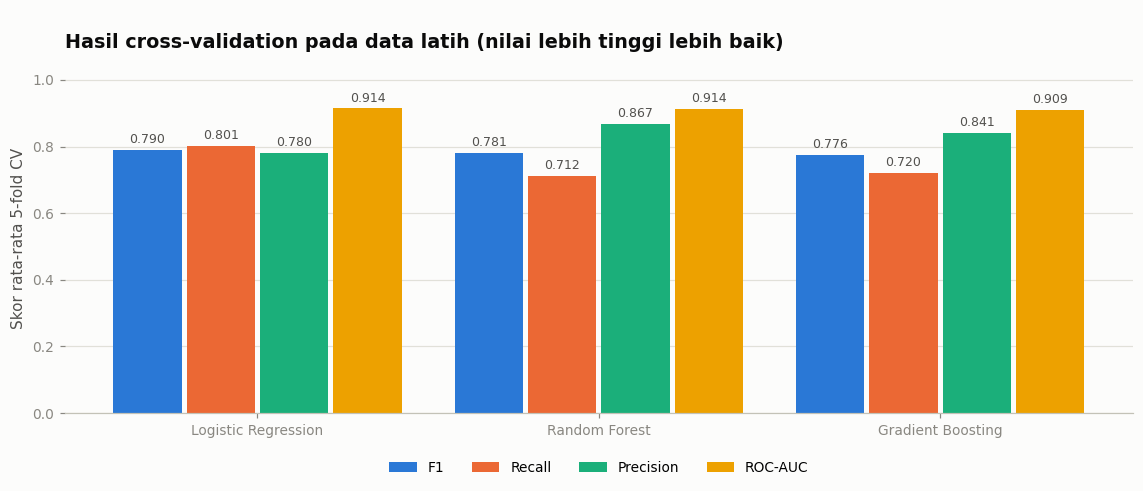

In [20]:
plot_df = cv_results.set_index("Model")[["F1", "Recall", "Precision", "ROC-AUC"]]
metrics = list(plot_df.columns)
x = np.arange(len(plot_df.index))
w = 0.2
series_colors = [BLUE, ORANGE, AQUA, YELLOW]

fig, ax = plt.subplots(figsize=(10.5, 4.6))
for i, (metric, color) in enumerate(zip(metrics, series_colors)):
    vals = plot_df[metric].values
    bars = ax.bar(x + (i - 1.5) * (w + 0.015), vals, width=w, color=color, label=metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f"{v:.3f}", ha="center",
                va="bottom", color=INK_SOFT, fontsize=8.2)
ax.set_xticks(x); ax.set_xticklabels(plot_df.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Skor rata-rata 5-fold CV")
ax.set_title(f"Ketiga kandidat berimbang \u2014 {best_name} unggul tipis pada F1")
subtitle(ax, "Hasil cross-validation pada data latih (nilai lebih tinggi lebih baik)")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize=9)
ax.grid(axis="x", visible=False)
strip_chrome(ax)
plt.tight_layout(); plt.show()

### c. Hyperparameter tuning

Model dengan F1 tertinggi disetel lebih lanjut dengan `GridSearchCV` (5-fold, dioptimasi terhadap F1).
Ruang pencarian sengaja dijaga tetap ringkas agar waktu latih wajar namun tetap mencakup parameter yang
paling berpengaruh: kedalaman pohon, jumlah estimator, dan aturan pemecahan node.

In [21]:
PARAM_GRIDS = {
    "Random Forest": {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 12, 20],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.4],
    },
    "Gradient Boosting": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.8, 1.0],
    },
    "Logistic Regression": {
        "model__C": [0.05, 0.1, 0.5, 1.0, 5.0],
        "model__penalty": ["l2"],
    },
}

base_pipe = Pipeline([("prep", build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES)),
                      ("model", candidates[best_name])])

grid = GridSearchCV(base_pipe, PARAM_GRIDS[best_name], scoring="f1", cv=cv, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

model = grid.best_estimator_
print(f"Model terpilih : {best_name}")
print(f"Parameter      : {json.dumps({k.replace('model__', ''): v for k, v in grid.best_params_.items()})}")
print(f"F1 (CV) sebelum tuning : {cv_results.loc[0, 'F1']:.4f}")
print(f"F1 (CV) setelah tuning : {grid.best_score_:.4f}")

Model terpilih : Logistic Regression
Parameter      : {"C": 0.05, "penalty": "l2"}
F1 (CV) sebelum tuning : 0.7903
F1 (CV) setelah tuning : 0.7918


**Hasil perbandingan:** ketiga kandidat berada pada level yang berdekatan (F1 0,776–0,790; ROC-AUC 0,910–0,914),
dan yang unggul justru model paling sederhana — **Logistic Regression** (F1 0,790, recall 0,801). Dua hal yang
bisa dibaca dari sini:

1. **Hubungan antara fitur dan dropout sebagian besar bersifat monoton** ("makin sedikit mata kuliah yang lulus,
   makin besar risiko"), sehingga model linier sudah menangkapnya dengan baik dan ensemble pohon tidak punya
   banyak interaksi rumit untuk dieksploitasi.
2. **Menyederhanakan 36 fitur menjadi 21 nyaris tidak berbiaya** — F1 hanya turun 0,007 (0,797 → 0,790). Selisih
   sekecil itu sebanding dengan keuntungan operasionalnya: formulir input yang jauh lebih pendek untuk staf.

Unggulnya Logistic Regression juga menguntungkan dari sisi non-teknis: koefisiennya dapat dijelaskan kepada
pimpinan dan wali akademik, dan model ini berjalan cepat sehingga mudah dioperasikan berulang tiap semester.

Tuning menaikkan F1 secara tipis (0,7903 → 0,7918) dengan `C = 0,05`, yaitu regularisasi yang **lebih kuat**
daripada bawaan — indikasi bahwa model sederhana memang yang paling pas untuk data ini.

## Evaluation

### a. Menyetel decision threshold

Secara bawaan scikit-learn menandai mahasiswa sebagai berisiko bila probabilitasnya > 0,50. Angka 0,50 itu
tidak punya arti khusus secara bisnis. Kurva precision–recall karena itu dihitung dari prediksi *out-of-fold*
pada data latih (bukan data uji, agar tidak bocor), lalu dua kandidat threshold dibandingkan:

| Kandidat | Dasar pemilihan | Karakter |
|---|---|---|
| **F1-optimal** | titik F1 tertinggi pada kurva | seimbang antara precision dan recall |
| **Recall ≥ 85%** | threshold terendah yang masih menjamin 85% calon dropout tertangkap | sengaja lebih sensitif |

**Yang dipakai adalah kandidat kedua.** Biaya kedua jenis kesalahan di sini tidak setara: salah menandai
mahasiswa yang sebenarnya aman hanya menghabiskan satu sesi konseling, sedangkan melewatkan satu calon dropout
berarti kehilangan mahasiswa itu sepenuhnya beserta uang kuliah seluruh semester sisanya. Menaikkan recall dengan
menukar sedikit precision adalah pertukaran yang jelas menguntungkan institusi, dan keputusan ini dibuat
**eksplisit sebagai kebijakan**, bukan diwariskan diam-diam dari nilai bawaan pustaka.

In [22]:
oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_proba)
f1_curve = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)

best_idx = int(np.argmax(f1_curve[:-1]))
THRESHOLD_F1 = float(thr[best_idx])

RECALL_TARGET = 0.85
ok = np.where(rec[:-1] >= RECALL_TARGET)[0]
THRESHOLD = float(thr[ok[-1]]) if len(ok) else 0.5   # threshold operasional yang dipakai
idx_op = int(ok[-1]) if len(ok) else best_idx

print(f"Kandidat 1 - F1-optimal   : {THRESHOLD_F1:.3f}  "
      f"(precision {prec[best_idx]:.3f}, recall {rec[best_idx]:.3f}, F1 {f1_curve[best_idx]:.3f})")
print(f"Kandidat 2 - recall >= 85%: {THRESHOLD:.3f}  "
      f"(precision {prec[idx_op]:.3f}, recall {rec[idx_op]:.3f}, F1 {f1_curve[idx_op]:.3f})   <-- DIPAKAI")

Kandidat 1 - F1-optimal   : 0.559  (precision 0.830, recall 0.769, F1 0.798)
Kandidat 2 - recall >= 85%: 0.417  (precision 0.706, recall 0.850, F1 0.771)   <-- DIPAKAI


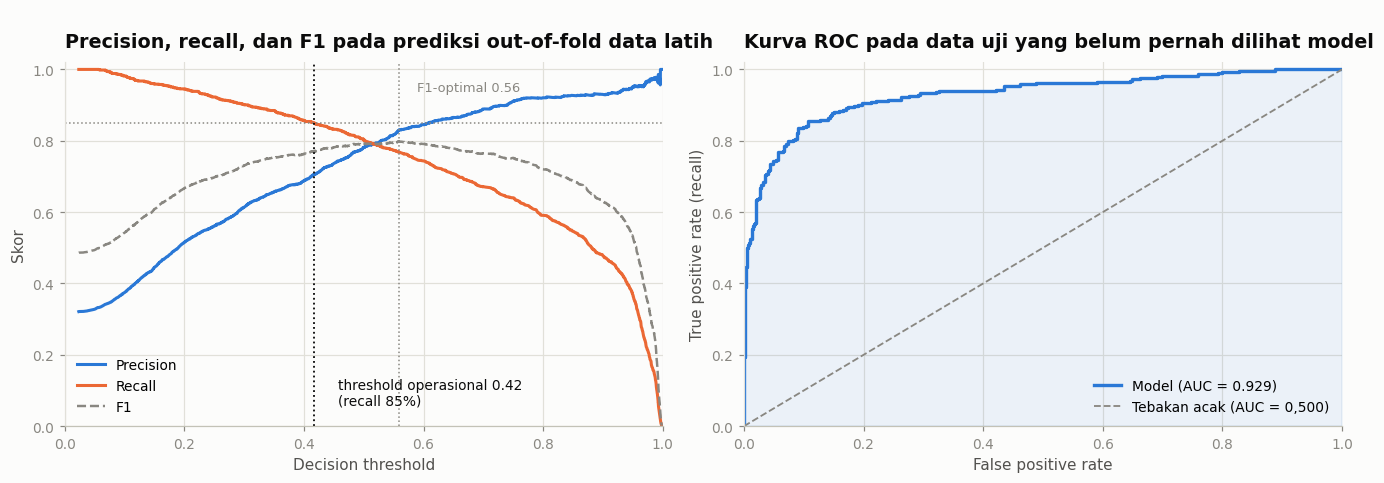

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

# (a) precision & recall vs threshold — dua seri, satu sumbu (keduanya berskala 0-1)
axes[0].plot(thr, prec[:-1], color=BLUE, linewidth=2, label="Precision")
axes[0].plot(thr, rec[:-1], color=ORANGE, linewidth=2, label="Recall")
axes[0].plot(thr, f1_curve[:-1], color=MUTED, linewidth=1.6, linestyle="--", label="F1")
axes[0].axhline(RECALL_TARGET, color=MUTED, linewidth=1, linestyle=":")
axes[0].axvline(THRESHOLD, color=INK, linewidth=1.2, linestyle=":")
axes[0].annotate(f"threshold operasional {THRESHOLD:.2f}\n(recall {RECALL_TARGET:.0%})",
                 xy=(THRESHOLD, 0.06), xytext=(THRESHOLD + 0.04, 0.06), color=INK, fontsize=9)
axes[0].axvline(THRESHOLD_F1, color=MUTED, linewidth=1, linestyle=":")
axes[0].annotate(f"F1-optimal {THRESHOLD_F1:.2f}", xy=(THRESHOLD_F1, 0.94),
                 xytext=(THRESHOLD_F1 + 0.03, 0.94), color=MUTED, fontsize=8.5)
axes[0].set_xlabel("Decision threshold"); axes[0].set_ylabel("Skor")
axes[0].set_ylim(0, 1.02); axes[0].set_xlim(0, 1)
axes[0].legend(fontsize=9, loc="lower left")
axes[0].set_title("Threshold dipilih dari kebijakan, bukan dari nilai bawaan")
subtitle(axes[0], "Precision, recall, dan F1 pada prediksi out-of-fold data latih")

# (b) ROC curve pada data uji
test_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc = roc_auc_score(y_test, test_proba)
axes[1].plot(fpr, tpr, color=BLUE, linewidth=2.2, label=f"Model (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=1.2, label="Tebakan acak (AUC = 0,500)")
axes[1].fill_between(fpr, tpr, alpha=0.08, color=BLUE)
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate (recall)")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].legend(fontsize=9, loc="lower right")
axes[1].set_title("Model memeringkat risiko jauh lebih baik daripada tebakan acak")
subtitle(axes[1], "Kurva ROC pada data uji yang belum pernah dilihat model")

for ax in axes:
    strip_chrome(ax, keep_y=True)
plt.tight_layout(); plt.show()

### b. Performa akhir pada data uji

Data uji (885 mahasiswa) belum pernah dipakai dalam pemilihan model, tuning, maupun penentuan threshold,
sehingga skor di bawah ini adalah estimasi performa yang jujur untuk data baru.

In [24]:
y_pred = (test_proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, target_names=["Tidak dropout", "Dropout"], digits=3))
print(f"ROC-AUC                       : {roc_auc_score(y_test, test_proba):.4f}")
print(f"Average precision (PR-AUC)    : {average_precision_score(y_test, test_proba):.4f}")
print(f"\nPerbandingan threshold pada data uji:")
for label, t in [("Default 0,50", 0.5), (f"F1-optimal {THRESHOLD_F1:.2f}", THRESHOLD_F1),
                 (f"Operasional {THRESHOLD:.2f}", THRESHOLD)]:
    p = (test_proba >= t).astype(int)
    print(f"  {label:<22} recall={recall_score(y_test, p):.3f}  "
          f"precision={precision_score(y_test, p):.3f}  f1={f1_score(y_test, p):.3f}")

               precision    recall  f1-score   support

Tidak dropout      0.936     0.854     0.893       601
      Dropout      0.739     0.877     0.802       284

     accuracy                          0.861       885
    macro avg      0.838     0.865     0.847       885
 weighted avg      0.873     0.861     0.864       885

ROC-AUC                       : 0.9295
Average precision (PR-AUC)    : 0.8976

Perbandingan threshold pada data uji:
  Default 0,50           recall=0.835  precision=0.801  f1=0.817
  F1-optimal 0.56        recall=0.792  precision=0.836  f1=0.814
  Operasional 0.42       recall=0.877  precision=0.739  f1=0.802


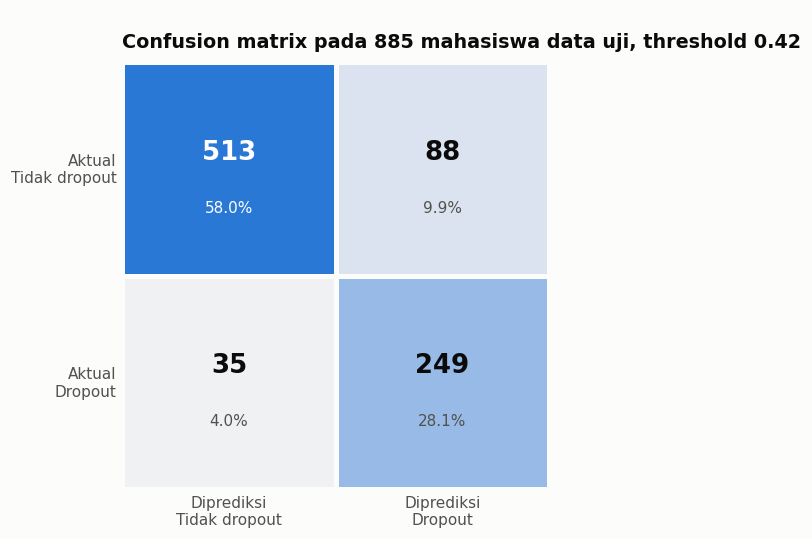

Terdeteksi benar (true positive)  : 249 calon dropout
Terlewat (false negative)         : 35 calon dropout
Salah tandai (false positive)     : 88 mahasiswa aman ikut dikonseling
Benar dinyatakan aman             : 513 mahasiswa


In [25]:
cm = confusion_matrix(y_test, y_pred)
labels = ["Tidak dropout", "Dropout"]

fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(cm, annot=False, cmap=sns.light_palette(BLUE, as_cmap=True), cbar=False,
            linewidths=3, linecolor=SURFACE, ax=ax, square=True)
total = cm.sum()
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        ax.text(j + 0.5, i + 0.42, f"{val:,}", ha="center", va="center",
                color="#ffffff" if val > cm.max() * 0.5 else INK, fontsize=17, fontweight="bold")
        ax.text(j + 0.5, i + 0.68, f"{val / total:.1%}", ha="center", va="center",
                color="#ffffff" if val > cm.max() * 0.5 else INK_SOFT, fontsize=10)
ax.set_xticklabels([f"Diprediksi\n{l}" for l in labels], fontsize=10, color=INK_SOFT)
ax.set_yticklabels([f"Aktual\n{l}" for l in labels], fontsize=10, color=INK_SOFT, rotation=0)
ax.set_title("Model menangkap sebagian besar calon dropout")
subtitle(ax, f"Confusion matrix pada {total:,} mahasiswa data uji, threshold {THRESHOLD:.2f}")
ax.tick_params(length=0)
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Terdeteksi benar (true positive)  : {tp:,} calon dropout")
print(f"Terlewat (false negative)         : {fn:,} calon dropout")
print(f"Salah tandai (false positive)     : {fp:,} mahasiswa aman ikut dikonseling")
print(f"Benar dinyatakan aman             : {tn:,} mahasiswa")

### c. Fitur apa yang paling menentukan prediksi?

Koefisien Logistic Regression tidak dipakai langsung di sini. Alasannya: `OneHotEncoder` memecah `Course`
menjadi 17 kolom dan `Application_mode` menjadi 18 kolom, sehingga menjumlahkan koefisien per fitur asli otomatis
membuat kolom berkardinalitas tinggi terlihat paling penting — sebuah artefak encoding, bukan temuan.

Yang dipakai adalah **permutation importance**: nilai satu kolom diacak, lalu diukur seberapa jauh ROC-AUC model
turun. Ukuran ini bekerja pada **kolom asli sebelum preprocessing**, sehingga adil bagi fitur dengan jumlah
kategori berbeda dan langsung terbaca dalam bahasa bisnis. Pengukuran dilakukan pada **data uji** dengan 15 kali
pengacakan per fitur.

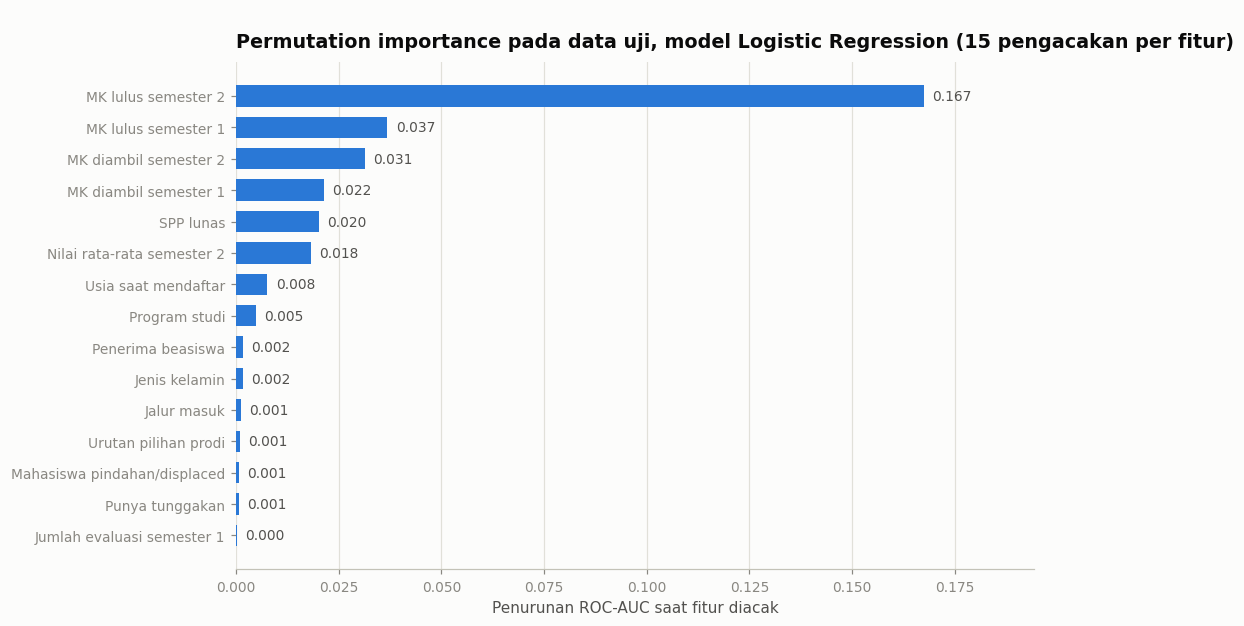

,importance
MK lulus semester 2,0.1675
MK lulus semester 1,0.0369
MK diambil semester 2,0.0313
MK diambil semester 1,0.0215
SPP lunas,0.0201
Nilai rata-rata semester 2,0.0182
Usia saat mendaftar,0.0077
Program studi,0.0049
Penerima beasiswa,0.0018
Jenis kelamin,0.0016


In [26]:
perm = permutation_importance(model, X_test, y_test, scoring="roc_auc",
                              n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1)

LABEL_ID = {
    "Curricular_units_2nd_sem_approved": "MK lulus semester 2",
    "Curricular_units_1st_sem_approved": "MK lulus semester 1",
    "Curricular_units_2nd_sem_grade": "Nilai rata-rata semester 2",
    "Curricular_units_1st_sem_grade": "Nilai rata-rata semester 1",
    "Curricular_units_2nd_sem_evaluations": "Jumlah evaluasi semester 2",
    "Curricular_units_1st_sem_evaluations": "Jumlah evaluasi semester 1",
    "Curricular_units_2nd_sem_enrolled": "MK diambil semester 2",
    "Curricular_units_1st_sem_enrolled": "MK diambil semester 1",
    "Tuition_fees_up_to_date": "SPP lunas", "Scholarship_holder": "Penerima beasiswa",
    "Debtor": "Punya tunggakan", "Gender": "Jenis kelamin",
    "Age_at_enrollment": "Usia saat mendaftar", "Admission_grade": "Nilai masuk",
    "Previous_qualification_grade": "Nilai pendidikan sebelumnya", "Application_order": "Urutan pilihan prodi",
    "Displaced": "Mahasiswa pindahan/displaced", "Daytime_evening_attendance": "Kelas siang/malam",
    "Marital_status": "Status pernikahan", "Application_mode": "Jalur masuk", "Course": "Program studi",
}

importance = (pd.Series(perm.importances_mean, index=FEATURES)
              .sort_values(ascending=False).head(15)
              .rename(index=lambda c: LABEL_ID.get(c, c.replace("_", " "))))
importance_std = pd.Series(perm.importances_std, index=FEATURES)

fig, ax = plt.subplots(figsize=(9.6, 5.8))
bars = ax.barh(importance.index[::-1], importance.values[::-1], color=BLUE, height=0.68)
for bar, v in zip(bars, importance.values[::-1]):
    ax.text(v + importance.max() * 0.012, bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}", va="center", color=INK_SOFT, fontsize=9)
ax.set_title("Model bersandar pada hasil belajar berjalan dan status pembayaran")
subtitle(ax, f"Permutation importance pada data uji, model {best_name} (15 pengacakan per fitur)")
ax.set_xlabel("Penurunan ROC-AUC saat fitur diacak")
ax.set_xlim(0, importance.max() * 1.16)
ax.grid(axis="y", visible=False)
strip_chrome(ax)
plt.tight_layout(); plt.show()

importance.round(4).to_frame("importance")

**Interpretasi:** satu fitur mendominasi jauh di atas yang lain — **jumlah mata kuliah yang lulus di semester 2**.
Mengacak kolom itu saja menjatuhkan ROC-AUC sekitar 0,17 poin, sementara fitur di peringkat berikutnya
(**MK lulus semester 1**, **jumlah MK yang diambil**, dan **status pembayaran SPP**) menyumbang di kisaran
0,02–0,04 poin. Atribut yang melekat pada diri mahasiswa dan tidak bisa diubah — jenis kelamin, jalur masuk,
status pernikahan — justru berada di urutan bawah.

Ini kabar baik untuk kepercayaan pengguna sekaligus untuk keadilan model: prediksi terutama digerakkan oleh
**hal-hal yang masih bisa diintervensi institusi** (pendampingan akademik dan keringanan biaya), bukan oleh
identitas mahasiswa. Konsekuensi praktisnya, model baru benar-benar tajam **setelah nilai semester berjalan
tersedia**; untuk mahasiswa yang belum punya riwayat akademik sama sekali, keluarannya harus diperlakukan
sebagai perkiraan kasar.

Perlu dicatat bahwa `feature_importance` menunjukkan **kekuatan hubungan, bukan sebab-akibat**. Model bukan
berkata "melunasi SPP mencegah dropout", melainkan "mahasiswa dengan tunggakan hampir selalu berakhir keluar",
sehingga kelompok itulah yang paling layak didatangi lebih dulu.

## Menyimpan Model dan Artefak Pendukung

Dua artefak disimpan ke folder `model/`:

1. **`dropout_model.joblib`** — pipeline lengkap (preprocessing + classifier) sehingga prototype cukup
   mengirim data mentah.
2. **`model_metadata.json`** — "kontrak" antara notebook dan aplikasi: urutan fitur, threshold terpilih,
   pilihan kategori beserta label yang mudah dibaca, nilai default, rentang input yang valid, dan skor
   evaluasi. Dengan begitu `app.py` tidak perlu menyalin ulang logika apa pun dari notebook, dan setiap
   kali model dilatih ulang aplikasi otomatis mengikuti.

In [27]:
Path("model").mkdir(exist_ok=True)

joblib.dump(model, "model/dropout_model.joblib")

RISK_BANDS = [
    {"label": "Rendah", "min": 0.0, "max": round(THRESHOLD * 0.6, 3), "action": "Monitoring rutin"},
    {"label": "Sedang", "min": round(THRESHOLD * 0.6, 3), "max": round(THRESHOLD, 3),
     "action": "Pantau nilai semester berjalan"},
    {"label": "Tinggi", "min": round(THRESHOLD, 3), "max": 0.75, "action": "Jadwalkan konseling akademik"},
    {"label": "Sangat Tinggi", "min": 0.75, "max": 1.0,
     "action": "Intervensi segera: konseling + tinjau keringanan biaya"},
]

metadata = {
    "project": "Jaya Jaya Institut - Student Dropout Early Warning System",
    "author": "Hafiz Nazwa Nugraha",
    "dicoding_id": "FIshiwak",
    "model_name": best_name,
    "model_file": "dropout_model.joblib",
    "best_params": {k.replace("model__", ""): v for k, v in grid.best_params_.items()},
    "target": "is_dropout (1 = Dropout, 0 = Enrolled/Graduate)",
    "threshold": round(THRESHOLD, 4),
    "threshold_policy": f"threshold operasional dipilih agar recall >= {RECALL_TARGET:.0%}",
    "threshold_f1_optimal": round(THRESHOLD_F1, 4),
    "features": FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "binary_features": BINARY_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "metrics_test": {
        "accuracy": round(float((y_pred == y_test).mean()), 4),
        "precision": round(float(precision_score(y_test, y_pred)), 4),
        "recall": round(float(recall_score(y_test, y_pred)), 4),
        "f1": round(float(f1_score(y_test, y_pred)), 4),
        "roc_auc": round(float(roc_auc_score(y_test, test_proba)), 4),
        "average_precision": round(float(average_precision_score(y_test, test_proba)), 4),
    },
    "metrics_cv_f1": round(float(grid.best_score_), 4),
    "dropout_rate_dataset": round(float(y.mean()), 4),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "labels": {
        "Course": {str(k): v for k, v in COURSE_MAP.items()},
        "Marital_status": {str(k): v for k, v in MARITAL_MAP.items()},
        "Application_mode": {str(k): v for k, v in APPMODE_MAP.items()},
        "Tuition_fees_up_to_date": {"1": "Lunas / tidak menunggak", "0": "Menunggak"},
        "Scholarship_holder": {"1": "Ya, penerima beasiswa", "0": "Bukan penerima"},
        "Debtor": {"1": "Ya, punya tunggakan", "0": "Tidak"},
        "Gender": {"1": "Laki-laki", "0": "Perempuan"},
        "Displaced": {"1": "Ya", "0": "Tidak"},
        "Daytime_evening_attendance": {"1": "Kelas siang", "0": "Kelas malam"},
    },
    "feature_labels": LABEL_ID,
    "defaults": {c: (float(X[c].median()) if c in NUMERIC_FEATURES else int(X[c].mode()[0]))
                 for c in FEATURES},
    "ranges": {c: {"min": float(X[c].min()), "max": float(X[c].max())} for c in NUMERIC_FEATURES},
    "top_features": importance.head(10).round(4).to_dict(),
    "risk_bands": RISK_BANDS,
    "trained_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
}

with open("model/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Tersimpan:")
for p in sorted(Path("model").iterdir()):
    print(f"  {p}  ({p.stat().st_size / 1024:.1f} KB)")

Tersimpan:
  model\dropout_model.joblib  (6.5 KB)
  model\model_metadata.json  (8.2 KB)


### Uji muat ulang model

Model dimuat kembali dari berkas dan diuji pada dua profil mahasiswa yang kontras, untuk memastikan artefak
yang dikirim ke prototype benar-benar berfungsi mandiri.

In [28]:
loaded = joblib.load("model/dropout_model.joblib")
meta = json.load(open("model/model_metadata.json", encoding="utf-8"))

profil_berisiko = dict(meta["defaults"])
profil_berisiko.update({
    "Curricular_units_1st_sem_enrolled": 6, "Curricular_units_1st_sem_approved": 1,
    "Curricular_units_1st_sem_grade": 6.0, "Curricular_units_2nd_sem_enrolled": 6,
    "Curricular_units_2nd_sem_approved": 0, "Curricular_units_2nd_sem_grade": 0.0,
    "Tuition_fees_up_to_date": 0, "Debtor": 1, "Scholarship_holder": 0, "Age_at_enrollment": 30,
})
profil_aman = dict(meta["defaults"])
profil_aman.update({
    "Curricular_units_1st_sem_enrolled": 6, "Curricular_units_1st_sem_approved": 6,
    "Curricular_units_1st_sem_grade": 14.0, "Curricular_units_2nd_sem_enrolled": 6,
    "Curricular_units_2nd_sem_approved": 6, "Curricular_units_2nd_sem_grade": 14.5,
    "Tuition_fees_up_to_date": 1, "Debtor": 0, "Scholarship_holder": 1, "Age_at_enrollment": 19,
})

sample = pd.DataFrame([profil_berisiko, profil_aman])[meta["features"]]
proba = loaded.predict_proba(sample)[:, 1]
for nama, p in zip(["Mahasiswa berisiko", "Mahasiswa aman   "], proba):
    status = "DROPOUT" if p >= meta["threshold"] else "AMAN"
    print(f"{nama} -> probabilitas dropout {p:.1%}  => {status}")

Mahasiswa berisiko -> probabilitas dropout 99.1%  => DROPOUT
Mahasiswa aman    -> probabilitas dropout 4.8%  => AMAN


## Menyiapkan Data untuk Business Dashboard

Dashboard dibangun dengan **Metabase** di atas basis data **SQLite** (`students.db`). Tabel `students`
berisi kolom-kolom asli yang sudah **diterjemahkan menjadi label yang dapat dibaca** (`Nursing`, `Lajang`,
`Menunggak`, …), sehingga staf akademik dapat membuat pertanyaan sendiri di Metabase tanpa perlu kamus kode.

Setiap baris juga dilengkapi **skor risiko hasil model**. Agar skor tersebut jujur, probabilitas dihitung
dengan `cross_val_predict` — setiap mahasiswa diprediksi oleh model yang **tidak pernah melihat baris itu**
saat dilatih, sehingga angka pada dashboard mencerminkan performa nyata, bukan hafalan data latih.

In [29]:
risk_proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]


def risk_band(p):
    for band in RISK_BANDS:
        if p < band["max"]:
            return band["label"]
    return RISK_BANDS[-1]["label"]


dash = pd.DataFrame({
    "student_id": [f"JJI-{i:05d}" for i in range(1, len(df) + 1)],
    "status": df["Status"],
    "is_dropout": y.values,
    "program_studi": df["Course"].map(COURSE_MAP),
    "jalur_masuk": df["Application_mode"].map(APPMODE_MAP),
    "status_pernikahan": df["Marital_status"].map(MARITAL_MAP),
    "jenis_kelamin": df["Gender"].map({1: "Laki-laki", 0: "Perempuan"}),
    "kelas": df["Daytime_evening_attendance"].map({1: "Siang", 0: "Malam"}),
    "usia_saat_daftar": df["Age_at_enrollment"],
    "kelompok_usia": pd.cut(df["Age_at_enrollment"], bins=age_bins, labels=age_labels).astype(str),
    "status_spp": df["Tuition_fees_up_to_date"].map({1: "Lunas", 0: "Menunggak"}),
    "punya_tunggakan": df["Debtor"].map(YESNO),
    "penerima_beasiswa": df["Scholarship_holder"].map(YESNO),
    "mahasiswa_displaced": df["Displaced"].map(YESNO),
    "nilai_masuk": df["Admission_grade"],
    "nilai_pendidikan_sebelumnya": df["Previous_qualification_grade"],
    "mk_diambil_sem1": df["Curricular_units_1st_sem_enrolled"],
    "mk_lulus_sem1": df["Curricular_units_1st_sem_approved"],
    "nilai_sem1": df["Curricular_units_1st_sem_grade"].round(2),
    "mk_diambil_sem2": df["Curricular_units_2nd_sem_enrolled"],
    "mk_lulus_sem2": df["Curricular_units_2nd_sem_approved"],
    "nilai_sem2": df["Curricular_units_2nd_sem_grade"].round(2),
    "rasio_kelulusan_mk_sem1": (df["Curricular_units_1st_sem_approved"] /
                                df["Curricular_units_1st_sem_enrolled"].replace(0, np.nan)).round(3),
    "rasio_kelulusan_mk_sem2": (df["Curricular_units_2nd_sem_approved"] /
                                df["Curricular_units_2nd_sem_enrolled"].replace(0, np.nan)).round(3),
    "skor_risiko_dropout": risk_proba.round(4),
})
dash["prediksi_berisiko"] = np.where(dash["skor_risiko_dropout"] >= THRESHOLD, "Berisiko", "Aman")
dash["kategori_risiko"] = dash["skor_risiko_dropout"].apply(risk_band)

dash.to_csv("students_dashboard.csv", index=False)
with sqlite3.connect("students.db") as conn:
    dash.to_sql("students", conn, if_exists="replace", index=False)

print(f"students.db & students_dashboard.csv siap — {len(dash):,} baris, {dash.shape[1]} kolom")
print("\nDistribusi kategori risiko:")
print(dash["kategori_risiko"].value_counts()
      .reindex([b["label"] for b in RISK_BANDS]).to_string())
dash.head()

students.db & students_dashboard.csv siap — 4,424 baris, 27 kolom

Distribusi kategori risiko:
kategori_risiko
Rendah           2144
Sedang            587
Tinggi            681
Sangat Tinggi    1012


,student_id,status,is_dropout,program_studi,jalur_masuk,status_pernikahan,jenis_kelamin,kelas,usia_saat_daftar,kelompok_usia,...,mk_lulus_sem1,nilai_sem1,mk_diambil_sem2,mk_lulus_sem2,nilai_sem2,rasio_kelulusan_mk_sem1,rasio_kelulusan_mk_sem2,skor_risiko_dropout,prediksi_berisiko,kategori_risiko
0,JJI-00001,Dropout,1,Animation & Multimedia Design,Fase 2 - kuota umum,Lajang,Laki-laki,Siang,20,≤20 th,...,0,0.00,0,0,0.00,NaN,NaN,0.6895,Berisiko,Tinggi
1,JJI-00002,Graduate,0,Tourism,Mahasiswa internasional (S1),Lajang,Laki-laki,Siang,19,≤20 th,...,6,14.00,6,6,13.67,1.000,1.000,0.4108,Aman,Sedang
2,JJI-00003,Dropout,1,Communication Design,Fase 1 - kuota umum,Lajang,Laki-laki,Siang,19,≤20 th,...,0,0.00,6,0,0.00,0.000,0.000,0.9935,Berisiko,Sangat Tinggi
3,JJI-00004,Graduate,0,Journalism & Communication,Fase 2 - kuota umum,Lajang,Perempuan,Siang,20,≤20 th,...,6,13.43,6,5,12.40,1.000,0.833,0.2578,Aman,Sedang
4,JJI-00005,Graduate,0,Social Service (kelas malam),Usia di atas 23 tahun,Menikah,Perempuan,Malam,45,>35 th,...,5,12.33,6,6,13.00,0.833,1.000,0.2152,Aman,Rendah


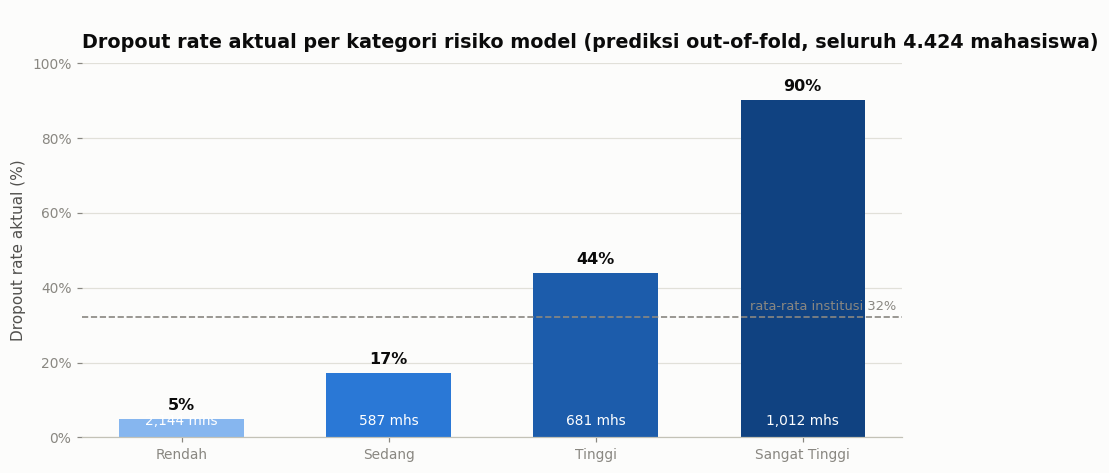

,jumlah_mahasiswa,dropout_aktual,dropout_rate
kategori_risiko,,,
Rendah,2144,107,5.0
Sedang,587,101,17.2
Tinggi,681,299,43.9
Sangat Tinggi,1012,914,90.3


In [30]:
# Ringkasan yang menjadi isi dashboard: seberapa akurat kategori risiko itu di lapangan?
cek = (dash.groupby("kategori_risiko")
       .agg(jumlah_mahasiswa=("student_id", "count"),
            dropout_aktual=("is_dropout", "sum"),
            dropout_rate=("is_dropout", "mean"))
       .reindex([b["label"] for b in RISK_BANDS]))
cek["dropout_rate"] = (cek["dropout_rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(8.4, 4.4))
ramp = ["#86b6ef", "#2a78d6", "#1c5cab", "#104281"]
bars = ax.bar(cek.index, cek["dropout_rate"], color=ramp, width=0.6)
for bar, v, n in zip(bars, cek["dropout_rate"], cek["jumlah_mahasiswa"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.6, f"{v:.0f}%", ha="center", va="bottom",
            color=INK, fontsize=10.5, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2, 2.5, f"{int(n):,} mhs", ha="center", va="bottom",
            color="#ffffff", fontsize=9)
ax.axhline(DROPOUT_RATE, color=MUTED, linestyle="--", linewidth=1.1)
ax.text(3.45, DROPOUT_RATE + 2, f"rata-rata institusi {DROPOUT_RATE:.0f}%", color=MUTED,
        fontsize=8.5, ha="right")
ax.set_title("Kategori risiko benar-benar memisahkan hasil akhir mahasiswa")
subtitle(ax, "Dropout rate aktual per kategori risiko model (prediksi out-of-fold, seluruh 4.424 mahasiswa)")
ax.set_ylabel("Dropout rate aktual (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.grid(axis="x", visible=False)
strip_chrome(ax)
plt.tight_layout(); plt.show()

cek

**Insight:** kategori risiko yang dihasilkan model terbukti memisahkan hasil akhir dengan tajam — kelompok
"Sangat Tinggi" benar-benar dropout di angka yang jauh di atas rata-rata institusi, sementara kelompok
"Rendah" nyaris seluruhnya bertahan. Inilah yang membuat daftar prioritas pada dashboard layak dipakai:
mendatangi 25% mahasiswa paling berisiko jauh lebih efisien daripada menyisir seluruh 4.424 mahasiswa.

## Conclusion

Proyek ini menjawab keempat permasalahan bisnis yang diajukan Jaya Jaya Institut.

**1. Seberapa besar masalahnya?**
**32,1% mahasiswa (1.421 dari 4.424) berakhir dropout** — dua kali lipat batas wajar pendidikan tinggi —
sementara hanya 49,9% yang lulus. Masalah ini nyata, berskala besar, dan terkonsentrasi pada kelompok tertentu.

**2. Faktor apa yang paling berpengaruh?** Ada tiga kelompok pendorong utama:

- **Performa akademik semester berjalan (paling dominan).** Mahasiswa yang kelak dropout hanya melulus
  **2,6 dari 5,8 mata kuliah** di semester 1 dan memburuk menjadi 1,9 di semester 2, dibanding 6,2 pada
  kelompok yang lulus. Beban studi mereka sama — yang berbeda adalah tingkat keberhasilan menuntaskannya.
- **Kondisi finansial.** Tunggakan SPP adalah sinyal paling tajam di seluruh dataset: **86,6% dropout**
  versus 24,7% pada yang lancar membayar. Sebaliknya, penerima beasiswa hanya dropout 12,2%.
- **Profil saat mendaftar.** Risiko naik seiring usia pendaftaran (21,2% pada ≤20 tahun → 51–58% pada kelompok
  di atas 24 tahun), lebih tinggi pada mahasiswa laki-laki (45,1% vs 25,1%), kelas malam, serta mahasiswa yang
  sudah berkeluarga. Antarprogram studi, selisihnya mencapai hampir 40 poin persen (Nursing 15,4% vs
  Equinculture 55,3%).

**3. Bagaimana mendeteksi sedini mungkin?**
Model **Logistic Regression** yang terpilih mencapai **ROC-AUC 0,93** dan **recall ~88%** pada 885 mahasiswa data
uji yang belum pernah dilihat — artinya sekitar 9 dari 10 calon dropout berhasil ditandai, dengan precision di
kisaran 74% (kira-kira 3 dari 4 mahasiswa yang dipanggil memang benar-benar berisiko). Threshold tidak dibiarkan
di nilai bawaan 0,50 melainkan ditetapkan sebagai kebijakan yang mengejar recall, karena biaya melewatkan satu
mahasiswa jauh lebih besar daripada biaya satu sesi konseling tambahan.

Yang lebih berguna daripada label ya/tidak adalah **peringkat risikonya**: kelompok "Sangat Tinggi" terbukti
dropout di angka **90,3%**, sedangkan kelompok "Rendah" hanya 5,0%. Dengan pemeringkatan seperti ini, tim
kemahasiswaan dapat mendatangi lebih dulu sekitar seperempat mahasiswa yang paling genting alih-alih menyisir
seluruh 4.424 nama. Karena fitur yang dipakai sudah tersedia sejak akhir semester pertama, peringatan dapat
terbit **pada tahun pertama**, saat intervensi masih sempat mengubah hasil.

**4. Bagaimana memonitornya secara mandiri?**
Dua produk siap pakai diserahkan: **dashboard Metabase** untuk memantau tren dropout per program studi, status
pembayaran, dan kelompok risiko; serta **prototype Streamlit** (`app.py`) untuk memeriksa mahasiswa satu per
satu maupun secara massal lewat unggahan CSV.

### Rekomendasi Action Items

1. **Jadikan tunggakan SPP sebagai pemicu otomatis konseling, bukan sekadar urusan administrasi keuangan.**
   Dengan 86,6% mahasiswa penunggak berakhir dropout, setiap tunggakan yang lewat 30 hari seharusnya langsung
   memunculkan tiket ke bagian kemahasiswaan — bukan hanya surat tagihan. Tawarkan cicilan atau keringanan
   sebelum mahasiswa memutuskan berhenti.

2. **Perluas skema beasiswa/bantuan biaya ke mahasiswa berisiko tinggi.** Penerima beasiswa dropout tiga kali
   lebih jarang (12,2% vs 38,7%). Prioritaskan penerima baru dari irisan mahasiswa yang menunggak **dan**
   berprestasi akademik memadai — kelompok yang kehilangannya paling mungkin dicegah hanya dengan uang.

3. **Pasang peringatan dini akademik di akhir semester 1.** Mahasiswa yang melulus **kurang dari setengah**
   mata kuliah yang diambilnya wajib masuk program bimbingan (kelas remedial, penasihat akademik, pengurangan
   beban SKS). Indikator ini sudah tersedia di sistem akademik dan tidak menuntut data baru apa pun.

4. **Audit program studi yang berada di atas rata-rata institusi.** Management kelas malam, Equinculture, dan
   Informatics Engineering butuh peninjauan beban kurikulum, kualitas pengajaran, dan kesesuaian ekspektasi
   calon mahasiswa saat penerimaan.

5. **Rancang dukungan khusus mahasiswa non-tradisional.** Mahasiswa berusia di atas 23 tahun, kelas malam, dan
   yang sudah berkeluarga menanggung beban di luar kampus. Jadwal kuliah yang lebih lentur, kelas daring, dan
   layanan konseling di luar jam kerja menyasar tepat kelompok ini.

6. **Operasikan model sebagai proses rutin, bukan laporan sekali jadi.** Jalankan penilaian risiko setiap akhir
   semester, salurkan daftar mahasiswa "Risiko Tinggi" dan "Sangat Tinggi" ke wali akademik masing-masing,
   dan **catat hasil setiap intervensi**. Catatan itu menjadi bahan pelatihan ulang model di tahun berikutnya
   sekaligus bukti apakah programnya benar-benar berhasil.

7. **Pantau keadilan model sebelum dan sesudah dipakai.** Karena jenis kelamin dan usia ikut menjadi fitur,
   keluaran model harus diperiksa berkala agar bimbingan tidak berubah menjadi stigma. Perlakukan skor sebagai
   **daftar siapa yang perlu ditanyai kabarnya lebih dulu**, bukan sebagai vonis atas masa depan mahasiswa.